# Trabajo Semanal 0 - Catalina Wynne
## Introducción
En este trabajo se implementa una función capaz de generar señales senoidales discretas a partir de distintos parámetros:como amplitud, valor medio, frecuencia, fase, cantidad de muestras, frecuencia de muestreo.

El objetivo es simular un proceso de muestreo de una señal continua y analizar el comportamiento de la señal si variamos su frecuencia.

Además, se estudia la frecuencia de Nyquist y el fenómeno de aliasing, observando cómo afectan la representación de las señales en tiempo discreto.

La forma general de una señal senoidal es: 

                          x(t) = A*sin(2* π*f*t + ϕ) + DC

donde: 

vmax : amplitud (A);

ff : frecuencia (Hz);

t : tiempo; 

ph : fase (ϕ);

DC : valor medio.

### Frecuencia de Nyquist y teorema de muestreo
La frecuencia de Nyquist se define como:

                                fN = fs/2

En este trabajo: fs = 1000 Hz → fN = 500 Hz

El teorema de muestreo establece que una señal puede ser representada correctamente si:

                                 fs ≥ 2*fmax
                                 
Cuando esta condición se cumple, la señal se representa correctamente y, cuando no se cumple, aparece el fenómeno de aliasing.

       

## Desarrollo
### Librerias


In [1]:
#importo las librerias que necesito usar
import numpy as np
import matplotlib.pyplot as plt

### Parámetros

In [2]:
N = 1000 #cantidad de muestras
fs = 1000 #frecuencia de muestreo

### Función seno

In [3]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    n = np.arange(nn)
    tt = n / fs
#Señal senoidal
    xx = dc + vmax*np.sin(2*np.pi*ff*tt + ph)

    return tt, xx

### Gráfico de prueba

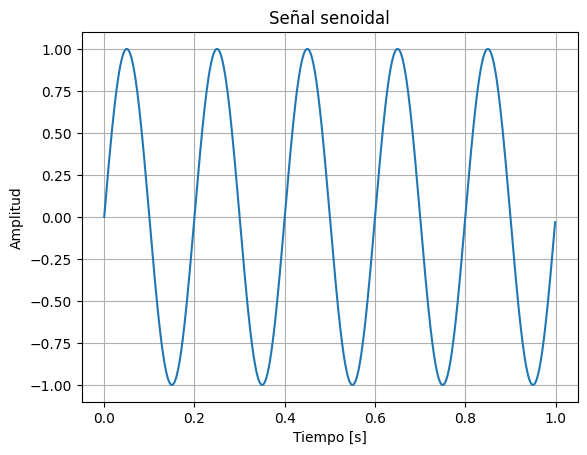

In [4]:
tt, xx = mi_funcion_sen(ff=5)

plt.plot(tt, xx)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal senoidal")
plt.grid()

plt.show()

### Gráficos en conjunto 

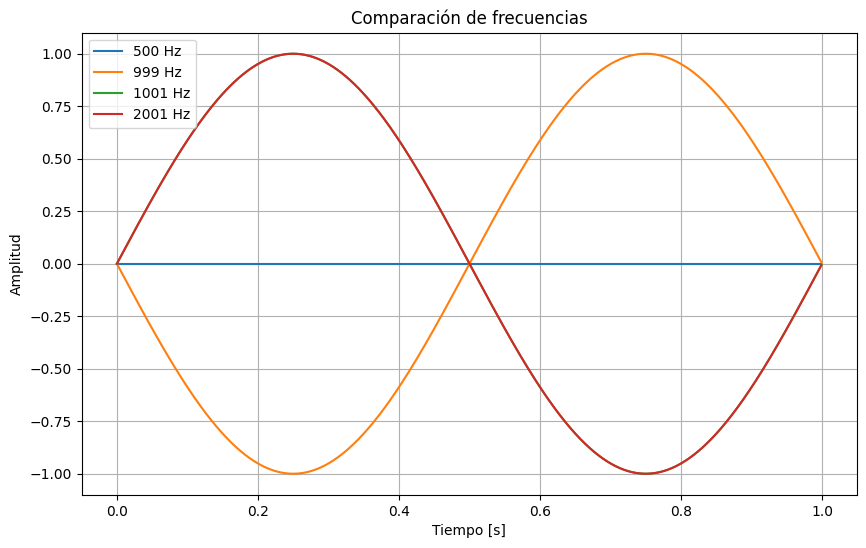

In [5]:
frecuencias = [500, 999, 1001, 2001]

plt.figure(figsize=(10,6))

for f in frecuencias:
    tt, xx = mi_funcion_sen(ff=f)
    plt.plot(tt, xx, label=f"{f} Hz")

plt.legend()
plt.title("Comparación de frecuencias")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

Aca se pueden observar todos los gráficos con las señales y distintas frecuencias, me estaba costando ver que pasaba con cada una bien asi que decidi graficar por separado para ver bien que pasaba

### Gráficos por separado

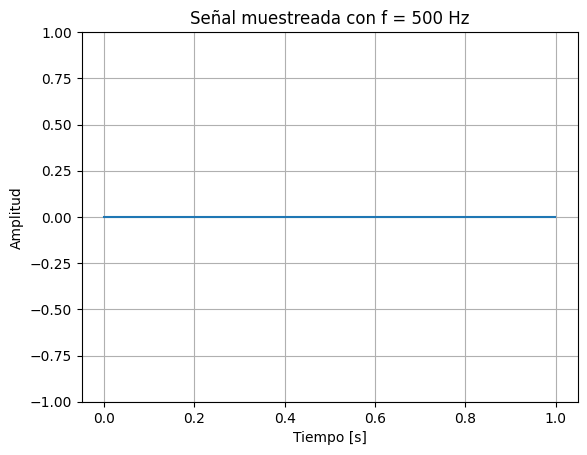

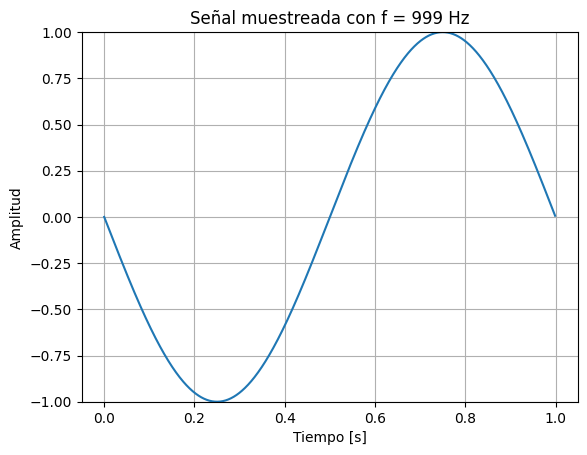

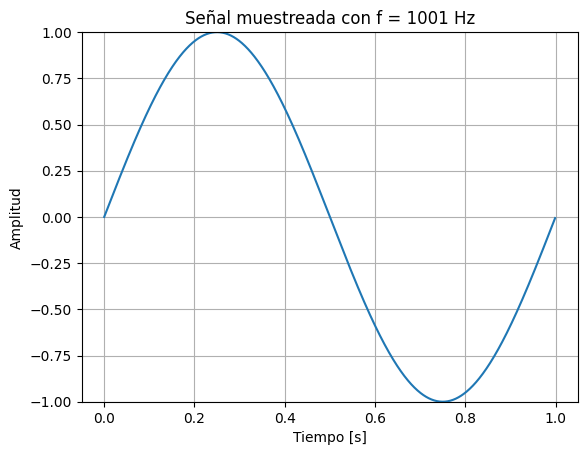

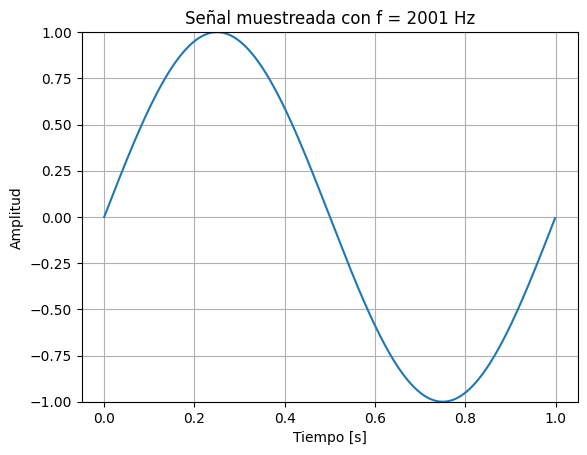

In [6]:
frecuencias = [500, 999, 1001, 2001]

for f in frecuencias:

    tt, xx = mi_funcion_sen(ff=f)

    plt.figure()
    plt.plot(tt, xx)
    plt.title(f"Señal muestreada con f = {f} Hz")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.ylim (-1,1)
    plt.grid()
    plt.show()

Se puede observar que señales de distintas frecuencias (999 Hz, 1001 Hz y 2001 Hz) generan formas muy similares al ser muestreadas.

Esto ocurre porque dichas frecuencias superan la frecuencia de Nyquist (500 Hz), por lo que el sistema de muestreo no puede representarlas correctamente.

Cuando se muestrea una señal, las frecuencias que difieren en múltiplos de la frecuencia de muestreo no pueden distinguirse entre sí.

En este caso:

999 Hz = fs - 1  → Se observa como 1 Hz

1001 Hz = fs + 1 → Se observa como 1 Hz

2001 Hz = 2·fs + 1 → Se observa como 1 Hz

Por lo tanto, todas estas señales generan la misma representación en tiempo discreto. Este fenómeno se conoce como aliasing

## Análisis y Conclusiones de los gráficos
#### Caso 1 ff = 500 Hz
La señal se encuentra en el límite de la frecuencia de Nyquist (500 Hz). En este caso, hay muy pocas muestras por período, lo que genera una representación poco precisa.

Esta es una situación límite donde el teorema de Nyquist apenas se cumple, pero la calidad de la señal es baja.
#### Caso 2 ff = 999 Hz
La frecuencia supera ampliamente la frecuencia de Nyquist. La señal observada no corresponde a la real sino a una frecuencia alias.

La señal sufre de aliasing y se observa como una señal de baja frecuencia.
#### Caso 3 ff = 1001 Hz
Esta señal también supera la frecuencia de Nyquist. Se comporta de manera similar al caso anterior.

Se observa el mismo alias que en la ff = 999 Hz, demostrando que distintas frecuencias pueden producir la misma señal discreta.
#### Caso 4 ff = 2001 Hz
La frecuencia es muy superior a la de muestreo. Aplicando el concepto de aliasing: 

2001 HZ = 2·fs +1 -- alias = 1 Hz.

La señal se observa como una señal de muy baja frecuencia, evidenciando una pérdida total de información.


### Señal Cuadrada bonus:
Implementé una señal cuadrada a partir de una señal senoidal, utilizando la función signo. No es una señal de frecuencia única, sino que contiene múltiples armónicos.

De esta manera, los valores positivos de la senoide se transforman en valores constante positivos y en los negativos sucede lo mismo, generando así una señal cuadrada.

In [7]:
def mi_funcion_cuadrada(vmax=1, dc=0, ff=1, nn=N, fs=fs):

    n = np.arange(nn)
    tt = n / fs

    xx = dc + vmax * np.sign(np.sin(2*np.pi*ff*tt))

    return tt, xx

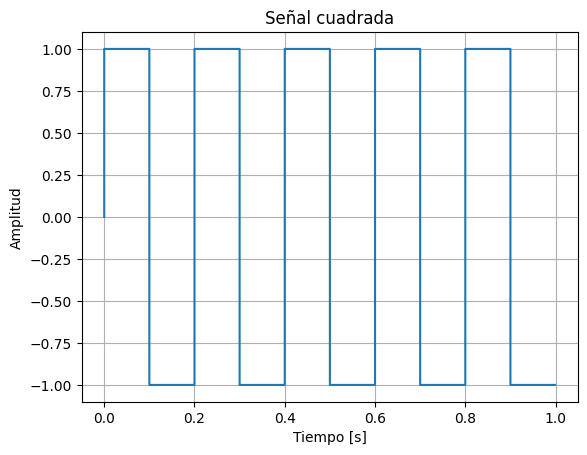

In [8]:
tt, xx = mi_funcion_cuadrada(ff=5)

plt.step(tt, xx)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal cuadrada")
plt.grid()
plt.show()

### Conclusión
Las señales no sinusoidales tienen mayor contenido frecuencial, por lo que son mas sensibles al aliasing.

### CONCLUSIONES FINALES
En este trabajo se implementó un generador de señales senoidales discretas y se analizó su comportamiento frente al proceso de muestreo.

Se observó que el teorema de Nyquist se cumple únicamente cuando la frecuencia de la señal es menor o igual a la mitad de la frecuencia de muestreo.

Cuando esta condición no se cumple, aparece el fenómeno de aliasing, donde distintas señales en tiempo continuo se vuelven indistinguibles en tiempo discreto.

Se  verificó experimentalmente que las frecuencias 999 Hz, 1001 Hz y 2001 Hz generan la misma representación, correspondiente a una frecuencia de aproximadamente 1 Hz.

Además, se comprendió que señales más complejas, como la señal cuadrada, contienen múltiples componentes frecuenciales, lo que aumenta la probabilidad de distorsión por aliasing.

### Aprendizajes
Aprendí a generar señales discretas en Python, a interpretar el proceso de muestreo y a aplicar el teorema de Nyquist.

Además, pude identificar el fenómeno de aliasing y comprender cómo afecta la representación de las señales cuando no se cumplen las condiciones de muestreo adecuadas.
